In [1]:
# --- Cell 1: imports + config ---
%load_ext autoreload
%autoreload 2
import sys, torch, numpy as np
sys.path.append('..')
sys.path.append('../..')

from common.seed import set_seed
from common.io_utils import save_results, load_results
from task4.img_prep.cifar_data import build_known_loaders, build_transforms
from task4.backbones.resnet_cifar import CifarResNet18
from task4.training.train_loop import train_model
from task4.methods.gcsc import GCSC
from task4.evaluations.metrics import extract_outputs, accuracy, macro_f1, per_class_accuracy

set_seed(6304)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_ROOT = '../../datasets'
splits = load_results('../../shared/splits/cifar10_seed6304.json')

CFG = dict(seed=6304, num_classes=10, batch_size=128, eval_batch=512, num_workers=0,
           epochs=100, lr=0.1, momentum=0.9, weight_decay=5e-4,
           schedule='cosine', randaugment=True, amp=False)   # <-- the ONLY change
print(device, torch.cuda.get_device_name(0) if device.type == 'cuda' else '')

cuda NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
# --- Cell 2: VERIFICATION — config differs from Vanilla in exactly one key,
#     and RandAugment is in the TRAIN transform only ---
van = load_results('../results/vanilla.json')['config']
diff = {k for k in set(CFG) | set(van) if CFG.get(k) != van.get(k)}
print('config keys that differ from Vanilla :', diff, '(expect {randaugment})')

tr_aug, ev_aug = build_transforms(randaugment=True)
tr_pln, ev_pln = build_transforms(randaugment=False)
names = lambda c: [type(t).__name__ for t in c.transforms]
print('GCSC train pipeline   :', names(tr_aug))
print('Vanilla train pipeline:', names(tr_pln))
print('eval pipelines match  :', names(ev_aug) == names(ev_pln), names(ev_pln))
print('RandAugment before ToTensor:',
      names(tr_aug).index('RandAugment') < names(tr_aug).index('ToTensor'))

ra = [t for t in tr_aug.transforms if type(t).__name__ == 'RandAugment'][0]
print('RandAugment settings  : num_ops =', ra.num_ops, '| magnitude =', ra.magnitude)

config keys that differ from Vanilla : {'randaugment'} (expect {randaugment})
GCSC train pipeline   : ['RandomCrop', 'RandomHorizontalFlip', 'RandAugment', 'ToTensor', 'Normalize']
Vanilla train pipeline: ['RandomCrop', 'RandomHorizontalFlip', 'ToTensor', 'Normalize']
eval pipelines match  : True ['ToTensor', 'Normalize']
RandAugment before ToTensor: True
RandAugment settings  : num_ops = 2 | magnitude = 9


In [3]:
# --- Cell 3: train GCSC ---
set_seed(6304)
loaders = build_known_loaders(DATA_ROOT, splits, batch_size=CFG['batch_size'],
                              eval_batch=CFG['eval_batch'], num_workers=CFG['num_workers'],
                              seed=CFG['seed'], randaugment=CFG['randaugment'])
model = CifarResNet18(num_classes=CFG['num_classes']).to(device)
method = GCSC(CFG).to(device)
out = train_model(model, method, loaders, CFG, device,
                  ckpt_path='../../datasets/cache/task4_gcsc.pt')
print(f"best epoch {out['best_epoch']}  val_acc {out['best_val_acc']:.4f}  {out['minutes']:.1f} min")

ep001 lr=0.1000 loss_cls=2.1488 train_acc=0.2425 | val_acc=0.3760 | best=0.3760@1 | 1.1m
ep002 lr=0.1000 loss_cls=1.6312 train_acc=0.3983 | val_acc=0.4906 | best=0.4906@2 | 2.8m
ep003 lr=0.0999 loss_cls=1.3977 train_acc=0.4939 | val_acc=0.5574 | best=0.5574@3 | 4.6m
ep005 lr=0.0996 loss_cls=1.0605 train_acc=0.6246 | val_acc=0.6812 | best=0.6812@5 | 8.2m
ep010 lr=0.0980 loss_cls=0.6809 train_acc=0.7655 | val_acc=0.7514 | best=0.7804@9 | 17.0m
ep015 lr=0.0952 loss_cls=0.5767 train_acc=0.8028 | val_acc=0.7776 | best=0.8118@14 | 25.6m
ep020 lr=0.0914 loss_cls=0.5278 train_acc=0.8185 | val_acc=0.8424 | best=0.8458@17 | 33.9m
ep025 lr=0.0864 loss_cls=0.4905 train_acc=0.8314 | val_acc=0.8438 | best=0.8558@24 | 40.6m
ep030 lr=0.0806 loss_cls=0.4653 train_acc=0.8394 | val_acc=0.8146 | best=0.8558@24 | 46.3m
ep035 lr=0.0741 loss_cls=0.4331 train_acc=0.8543 | val_acc=0.8690 | best=0.8690@35 | 53.8m
ep040 lr=0.0669 loss_cls=0.4052 train_acc=0.8596 | val_acc=0.8640 | best=0.8720@37 | 57.8m
ep045 lr

In [4]:
# --- Cell 4: freeze  ---

cache = {}
for split in ['train_eval', 'val', 'test']:
    o = extract_outputs(model, loaders[split], device, keep_features=True)
    cache[f'{split}_logits'] = o['logits']
    cache[f'{split}_features'] = o['features']
    cache[f'{split}_labels'] = o['labels']
    print(f"{split:11s} logits {o['logits'].shape}  features {o['features'].shape}")

np.savez_compressed('../../datasets/cache/task4_gcsc_known.npz', **cache)

csa = accuracy(cache['test_logits'], cache['test_labels'])
van_csa = load_results('../results/vanilla.json')['test_accuracy']
print(f"\nGCSC CIFAR-10 TEST accuracy (CSA) : {csa:.4f}")
print(f"Vanilla CSA                       : {van_csa:.4f}")
print(f"delta CSA                         : {csa - van_csa:+.4f}")
pc = per_class_accuracy(cache['test_logits'], cache['test_labels'])
for c, name in enumerate(splits['classes']):
    print(f"  {name:12s} {pc[c]:.4f}")

train_eval  logits (45000, 10)  features (45000, 512)
val         logits (5000, 10)  features (5000, 512)
test        logits (10000, 10)  features (10000, 512)

GCSC CIFAR-10 TEST accuracy (CSA) : 0.9507
Vanilla CSA                       : 0.9461
delta CSA                         : +0.0046
  airplane     0.9610
  automobile   0.9800
  bird         0.9470
  cat          0.8760
  deer         0.9620
  dog          0.9160
  frog         0.9660
  horse        0.9740
  ship         0.9680
  truck        0.9570


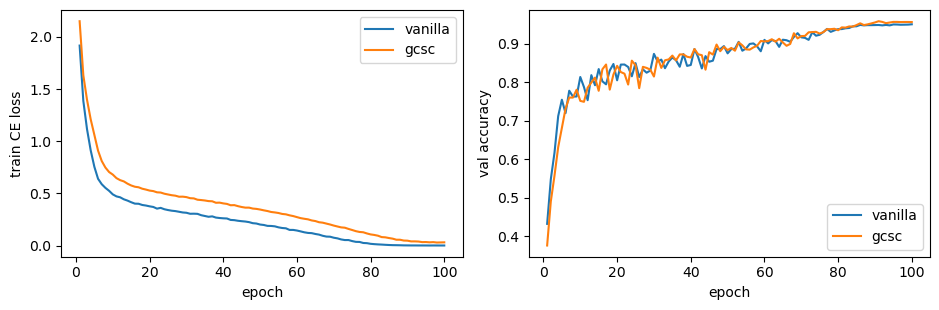

In [5]:
# --- Cell 5: save results + curves ---
results = {'step': 'gcsc', 'seed': 6304, 'method': 'gcsc', 'config': CFG,
           'steps_per_epoch': loaders['steps_per_epoch'],
           'best_epoch': out['best_epoch'], 'best_val_acc': out['best_val_acc'],
           'test_accuracy': csa,
           'test_macro_f1': macro_f1(cache['test_logits'], cache['test_labels']),
           'delta_csa_vs_vanilla': csa - van_csa,
           'per_class_test_accuracy': {n: float(pc[i]) for i, n in enumerate(splits['classes'])},
           'minutes': out['minutes'], 'history': out['history'],
           'cache_file': 'datasets/cache/task4_gcsc_known.npz'}
save_results(results, '../results/gcsc.json')

import matplotlib.pyplot as plt
h = out['history']; hv = load_results('../results/vanilla.json')['history']
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.2))
ax[0].plot([r['epoch'] for r in hv], [r['loss_cls'] for r in hv], label='vanilla')
ax[0].plot([r['epoch'] for r in h],  [r['loss_cls'] for r in h],  label='gcsc')
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('train CE loss'); ax[0].legend()
ax[1].plot([r['epoch'] for r in hv], [r['val_acc'] for r in hv], label='vanilla')
ax[1].plot([r['epoch'] for r in h],  [r['val_acc'] for r in h],  label='gcsc')
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('val accuracy'); ax[1].legend()
plt.tight_layout(); plt.savefig('../../report/figures/task4_gcsc_vs_vanilla.png', dpi=200)
plt.show()